<a href="https://colab.research.google.com/github/HoFangHuy/AI/blob/main/BTVN-nhandienhoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

In [2]:
!pip install matplotlib
!pip install scikit-learn

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

In [4]:
from google.colab import files
import zipfile

uploaded = files.upload()

# Giải nén thư mục
for filename in uploaded.keys():
    if filename.endswith(".zip"):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall("/content/flower_data")


Saving ảnh train model.zip to ảnh train model.zip


In [5]:
zip_path = "/content/ảnh train model.zip"
extract_path = "/content/hoa_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

classes = sorted(os.listdir("/content/hoa_data/ảnh train model"))

img_size = (100, 100)
X = []
y = []

#load ảnh vào
for i, label in enumerate(classes):
    folder = os.path.join("/content/hoa_data/ảnh train model", label)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        try:
            img = load_img(img_path, target_size=img_size)
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(i)
        except:
            print("")

X = np.array(X)
y = to_categorical(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng mô hình ANN
model = Sequential([
    Flatten(input_shape=img_size + (3,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,848,709 (14.68 MB)

 Trainable params: 3,848,709 (14.68 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2289 - loss: 2.1460 - val_accuracy: 0.1667 - val_loss: 8.3584
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.2744 - loss: 8.6231 - val_accuracy: 0.1667 - val_loss: 13.7151
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1797 - loss: 12.6757 - val_accuracy: 0.5000 - val_loss: 1.4067
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3415 - loss: 2.5751 - val_accuracy: 0.3333 - val_loss: 4.6388
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4399 - loss: 4.0744 - val_accuracy: 0.0833 - val_loss: 5.4146
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4362 - loss: 3.5867 - val_accuracy: 0.3333 - val_loss: 2.0502
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5033 - loss: 1.8519 - val_accuracy: 0.5000 - val_loss: 1.4198
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5563 - loss: 1.1817 - val_accuracy: 0.3333 - val_loss: 2.7908


In [ ]:
model.save("nhan_dien_hoa.h5")

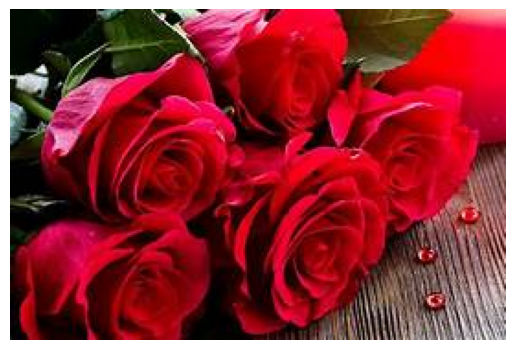

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
 Loài hoa dự đoán: **hoa hồng**
 Xác suất: 69.32%


In [19]:
def predict_image(img_path):
    img_display = load_img(img_path)
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

    img = load_img(img_path, target_size=(100, 100))
    img = img_to_array(img) / 255.0 #chuẩn hóa 0-1
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_index = np.argmax(pred)
    confidence = np.max(pred)

    print(f" Loài hoa dự đoán: **{classes[class_index]}**")
    print(f" Xác suất: {confidence * 100:.2f}%")

predict_image("/content/th.jpg")
